# 01 — Build the RSV-A / nirsevimab DMS benchmark table

**Purpose.** Turn the published RSV-A Long F deep-mutational-scanning (DMS) summary table into a
predefined, quality-controlled benchmark population of amino-acid substitutions that
(a) retain F-mediated cell-entry function and (b) have at least one nirsevimab escape measurement.

**This notebook does not perform the EVEscape comparison.** It only builds and QCs the experimental
side. The comparison is specified in [`../ANALYSIS_PLAN.md`](../ANALYSIS_PLAN.md) and is blocked on
obtaining the production RSV-A EVEscape score table (see [`../README.md`](../README.md)).

## Provenance

```
Simonich et al., bioRxiv 10.64898/2026.02.12.705519  (CC-BY 4.0)
  └─ Supplementary File 1  ≡  results/summaries/all_antibodies.csv
       └─ dms-vep/RSV_Long_F_DMS @ e01679cf2d0cc0a1038e46eb4a64f42e711ff838
            └─ THIS NOTEBOOK
                 └─ data/dms_nirsevimab_functional.csv
```

The paper states verbatim that Supplementary File 1 "is also available at
`https://github.com/dms-vep/RSV_Long_F_DMS/blob/main/results/summaries/all_antibodies.csv`",
so the upstream file is the published supplementary table rather than a re-derivation.

## Design notes

* The upstream commit hash is **asserted**, not merely recorded: the row counts below are valid for
  one upstream commit, and a silent upstream change should fail loudly rather than quietly alter the
  numbers.
* Section 3 **proves** the meaning of missing values by reconstructing all three measurement columns
  from the per-assay files under the pipeline's own filter parameters, reaching 100% agreement.
  Missing does not mean unmeasured, and that distinction changes how the population must be
  described.
* Every population is defined as an explicit boolean mask, so each count in the README traces to one
  line of code.
* The `> -2.5` filter is annotated with the verbatim sentence from the source paper, because it is
  the DMS authors' own published criterion rather than a threshold tuned here.
* The export is hash-verified against the shipped table, so "reproducible" is a checked claim.
* Section 8 measures how concentrated the escape signal is; that measurement is what determines the
  statistical design in `ANALYSIS_PLAN.md`.


## 1. Environment and upstream source

In [1]:
import hashlib
import os
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

pd.set_option("display.width", 120)

# Pinned upstream state. The counts in this notebook are valid for this commit only.
DMS_REPO_NAME = "RSV_Long_F_DMS"
DMS_REL_PATH = Path("results/summaries/all_antibodies.csv")
EXPECTED_COMMIT = "e01679cf2d0cc0a1038e46eb4a64f42e711ff838"


def find_upstream_repo(name, marker):
    # Walk upward from the notebook until the cloned upstream repo is found.
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidate = parent / name
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find {}/{} in any parent directory.\n"
        "Clone it next to this project:\n"
        "    git clone https://github.com/dms-vep/{}.git\n"
        "    git -C {} checkout {}".format(name, marker, name, name, EXPECTED_COMMIT)
    )


DMS_REPO = find_upstream_repo(DMS_REPO_NAME, DMS_REL_PATH)
DMS_PATH = DMS_REPO / DMS_REL_PATH

commit = subprocess.run(
    ["git", "-C", str(DMS_REPO), "rev-parse", "HEAD"], capture_output=True, text=True
).stdout.strip()

print("upstream repo   :", os.path.relpath(DMS_REPO, Path.cwd()))
print("upstream commit :", commit)
print("expected commit :", EXPECTED_COMMIT)
print("MATCH" if commit == EXPECTED_COMMIT else "!! COMMIT MISMATCH - counts below may differ !!")

upstream repo   : ../../RSV_Long_F_DMS
upstream commit : e01679cf2d0cc0a1038e46eb4a64f42e711ff838
expected commit : e01679cf2d0cc0a1038e46eb4a64f42e711ff838
MATCH


## 2. Load the published summary table

In [2]:
dms_raw = pd.read_csv(DMS_PATH)
print("shape:", dms_raw.shape)
print("\ncolumns:")
for c in dms_raw.columns:
    print("   ", c)

shape: (9824, 20)

columns:
    site
    wildtype
    mutant
    Nirsevimab-IgG escape
    Nirsevimab-Fab escape
    Clesrovimab-IgG escape
    Clesrovimab-Fab escape
    Palivizumab-IgG escape
    Palivizumab-Fab escape
    RSM01-IgG escape
    RSM01-Fab escape
    Suptavumab-IgG escape
    Suptavumab-Fab escape
    1A2-IgG escape
    1A2-Fab escape
    1B6-IgG escape
    1B6-Fab escape
    cell entry
    sequential_site
    region


### Column meanings (from the paper and `data/summaries_config.yml`)

| Column | Meaning | Direction |
|---|---|---|
| `site` | Standard RSV F numbering, position 1 = N-terminal Met of the 574-aa F. Range 26–529 = mutagenised ectodomain | — |
| `sequential_site` | Index within the 504-residue ectodomain construct (`site - 25`). Bookkeeping only — **never** use as a merge key | — |
| `region` | Broadly defined antigenic region (Gilman 2016 / Rossey 2018). Literal string `"none"` outside the six regions, not `NaN` | — |
| `cell entry` | log2 cell entry of the mutant pseudovirus **relative to unmutated Long F**, averaged over 6 functional selections | negative = impaired entry, ~0 = WT-like, positive = improved |
| `Nirsevimab-Fab escape` | `escape_median` from the `polyclonal` fit, Fab form | **positive = decreased neutralization** (= escape) |
| `Nirsevimab-IgG escape` | same, IgG form (the clinically administered form) | **positive = decreased neutralization** |

Only the nirsevimab columns are kept; the other five antibodies in the table are out of scope here.

In [3]:
COLS = [
    "site",
    "wildtype",
    "mutant",
    "Nirsevimab-IgG escape",
    "Nirsevimab-Fab escape",
    "cell entry",
    "sequential_site",
    "region",
]
dms = dms_raw[COLS].copy()

# Sanity: `sequential_site` is a pure offset of `site`, so it carries no extra information.
offsets = (dms["site"] - dms["sequential_site"]).unique()
assert offsets.tolist() == [25], offsets
print("site - sequential_site is constant:", offsets)
print("site range :", dms.site.min(), "-", dms.site.max(), "|", dms.site.nunique(), "sites")
print("regions    :", dms.region.unique().tolist())

site - sequential_site is constant: [25]
site range : 26 - 529 | 504 sites
regions    : ['region_I', 'region_III', 'region_V', 'region_0', 'none', 'region_II', 'region_IV']


## 3. What `NaN` actually means in the escape columns

This is the single most important thing to know before using the benchmark table.

A missing `Nirsevimab-Fab escape` value does **not** mean "this mutation was not measured".
`results/summaries/all_antibodies.csv` is produced by the dms-vep pipeline from
`data/summaries_config.yml`, which applies precision filters:

* `min_times_seen: 2` — the mutation must be seen on at least 2 unique barcodes
* `min_frac_models: 0.67` — it must be fit in at least 2/3 of the models. For the antibody assays
  this is the `frac_models` column; for cell entry, which has no `frac_models` column, the
  equivalent is `n_selections >= 0.67 x 6` (there are six functional selections)
* `le_filters: escape_std <= 1.75` for Nirsevimab-**Fab**, `<= 1.50` for Nirsevimab-**IgG**
* `le_filters: effect_std <= 1.60` for `cell entry`
* alphabet restricted to the 20 amino acids (stop `*` and gap `-` are dropped)

The paper describes the same step: *"We filtered the effects of mutations on antibody neutralization
to retain only mutations with at least two unique barcodes, excluded mutations with very low cell
entry scores, and excluded mutations that had high standard deviations in their effect on
neutralization across replicates."*

So `NaN` = **measured but filtered as imprecise** (or absent from the library). The cell below
proves this by rebuilding each column from the per-assay files under exactly those rules.

**Consequence for interpretation:** the benchmark population is *non-randomly censored* — noisy
estimates are removed preferentially. This must be stated whenever the benchmark is reported, and it
is why missing values are kept as `NaN` and **never** imputed to 0: a dropped noisy measurement is
not evidence of "no escape".

In [4]:
FILTERS = {
    "Nirsevimab-Fab escape": dict(
        src="results/antibody_escape/averages/Nirsevimab-Fab_mut_effect.csv",
        stat="escape_median", std_col="escape_std", std_max=1.75,
    ),
    "Nirsevimab-IgG escape": dict(
        src="results/antibody_escape/averages/Nirsevimab-IgG_mut_effect.csv",
        stat="escape_median", std_col="escape_std", std_max=1.50,
    ),
    "cell entry": dict(
        src="results/func_effects/averages/293T-TIM1_entry_func_effects.csv",
        stat="effect", std_col="effect_std", std_max=1.60,
    ),
}

# WT-identity rows exist only in the summary table, not in the per-assay files.
subs_only = dms_raw[dms_raw.wildtype != dms_raw.mutant]

MIN_TIMES_SEEN = 2
MIN_FRAC_MODELS = 0.67

for col, spec in FILTERS.items():
    up = pd.read_csv(DMS_REPO / spec["src"])
    keep = up[(up.times_seen >= MIN_TIMES_SEEN) & (up[spec["std_col"]] <= spec["std_max"])]
    if "frac_models" in up.columns:
        keep = keep[keep.frac_models >= MIN_FRAC_MODELS]
    else:
        # cell entry has no `frac_models`; the equivalent is the fraction of the six
        # functional selections in which the mutation was measured.
        keep = keep[keep.n_selections >= MIN_FRAC_MODELS * up.n_selections.max()]
    keep = keep[~keep.mutant.isin(["*", "-"])]

    recon = keep.set_index(["site", "mutant"])[spec["stat"]]
    published = subs_only.set_index(["site", "mutant"])[col]
    joined = published.to_frame("published").join(recon.rename("reconstructed"))
    agree = np.isclose(joined.published, joined.reconstructed, equal_nan=True).mean()
    print(
        "{:24s} published non-NaN={:5d}  reconstructed={:5d}  agreement={:.4%}".format(
            col, published.notna().sum(), joined.reconstructed.notna().sum(), agree
        )
    )

Nirsevimab-Fab escape    published non-NaN= 6903  reconstructed= 6903  agreement=100.0000%
Nirsevimab-IgG escape    published non-NaN= 7898  reconstructed= 7898  agreement=100.0000%
cell entry               published non-NaN= 9296  reconstructed= 9296  agreement=100.0000%


## 4. Mutation identifiers and removal of wildtype-identity rows

In [5]:
# Mutation ID in standard RSV F numbering: <wildtype><site><mutant>, e.g. K209N.
# `site` is the reference (not sequential) numbering, which is what a cross-study merge needs.
dms["mutation"] = dms["wildtype"] + dms["site"].astype(str) + dms["mutant"]

wt_identity = dms["wildtype"] == dms["mutant"]
print("rows before            :", len(dms))
print("wildtype-identity rows :", wt_identity.sum(), "(exactly one per site)")

# These rows encode the unmutated amino acid at each site, not a substitution.
dms = dms[~wt_identity].copy()
print("actual substitutions   :", len(dms))

assert wt_identity.sum() == dms_raw.site.nunique(), "expected exactly one WT row per site"
assert dms["mutation"].duplicated().sum() == 0, "mutation IDs must be unique"
assert (dms.wildtype + dms.site.astype(str) + dms.mutant == dms.mutation).all()
print("\nunique mutation IDs    :", dms.mutation.nunique(), "(no collisions)")

rows before            : 9824
wildtype-identity rows : 504 (exactly one per site)
actual substitutions   : 9320

unique mutation IDs    : 9320 (no collisions)


## 5. Functional filter: `cell entry > -2.5`

This threshold is **the paper's own published criterion**, not a choice made here. Simonich et al.
state it verbatim three times, e.g.:

> "…so these plots only show mutations that retain at least some moderate level of cell entry
> (**a cell entry effect > -2.5** in our measurements)."

The same value is the default in the companion repository
(`data/summaries_config.yml`: `init_min_value: -2.5`) and appears in every interactive plot linked
from the paper's homepage (`fi={"cell_entry":-2.5}`).

Note the strict inequality, and that `NaN` cell-entry values are **excluded** rather than treated as
passing or failing numerically. `NaN > -2.5` already evaluates to `False` in pandas, but the
exclusion is made explicit with `.notna()` so the intent is readable rather than incidental.

**This criterion is fixed here, before any EVEscape score has been inspected.**

In [6]:
CELL_ENTRY_MIN = -2.5  # Simonich et al.: "a cell entry effect > -2.5 in our measurements"

entry_measured = dms["cell entry"].notna()
retains_entry = entry_measured & (dms["cell entry"] > CELL_ENTRY_MIN)

dms_functional = dms[retains_entry].copy()

print("substitutions                 : {:5d}".format(len(dms)))
print("cell entry measured           : {:5d}".format(entry_measured.sum()))
print("cell entry > {:<4}             : {:5d}  ({:.2%} of measured)".format(
    CELL_ENTRY_MIN, len(dms_functional), len(dms_functional) / entry_measured.sum()))
print("minimum retained cell entry   : {:.3f}".format(dms_functional["cell entry"].min()))
print("rows exactly at the threshold : {}".format((dms["cell entry"] == CELL_ENTRY_MIN).sum()))

substitutions                 :  9320
cell entry measured           :  9296
cell entry > -2.5             :  4451  (47.88% of measured)
minimum retained cell entry   : -2.498
rows exactly at the threshold : 0


## 6. Benchmark population — explicit definitions

In [7]:
has_fab = dms_functional["Nirsevimab-Fab escape"].notna()
has_igg = dms_functional["Nirsevimab-IgG escape"].notna()

population = pd.DataFrame(
    {
        "n": [
            len(dms),
            entry_measured.sum(),
            len(dms_functional),
            has_fab.sum(),
            has_igg.sum(),
            (has_fab & has_igg).sum(),
            (has_fab | has_igg).sum(),
        ],
        "definition": [
            "wildtype != mutant",
            "  ... & cell entry notna",
            "  ... & cell entry > -2.5              [= FUNCTIONAL]",
            "FUNCTIONAL & Fab escape notna",
            "FUNCTIONAL & IgG escape notna",
            "FUNCTIONAL & Fab notna & IgG notna",
            "FUNCTIONAL & (Fab notna | IgG notna)   [= BENCHMARK]",
        ],
    },
    index=[
        "actual substitutions",
        "cell-entry measured",
        "functional",
        "functional + Fab",
        "functional + IgG",
        "functional + both",
        "functional + at least one",
    ],
)
display(population)

# Inclusion-exclusion must hold exactly: |Fab| + |IgG| - |both| = |union|
lhs = has_fab.sum() + has_igg.sum() - (has_fab & has_igg).sum()
rhs = (has_fab | has_igg).sum()
assert lhs == rhs, (lhs, rhs)
print("\nconsistency: {} + {} - {} = {} == {}  OK".format(
    has_fab.sum(), has_igg.sum(), (has_fab & has_igg).sum(), lhs, rhs))

,n,definition
actual substitutions,9320,wildtype != mutant
cell-entry measured,9296,... & cell entry notna
functional,4451,... & cell entry > -2.5 [= FUNC...
functional + Fab,3977,FUNCTIONAL & Fab escape notna
functional + IgG,4244,FUNCTIONAL & IgG escape notna
functional + both,3945,FUNCTIONAL & Fab notna & IgG notna
functional + at least one,4276,FUNCTIONAL & (Fab notna | IgG notna) [= BENC...



consistency: 3977 + 4244 - 3945 = 4276 == 4276  OK


## 7. Fab and IgG are not interchangeable

Simonich et al. build the paper on a biophysical model in which bivalent IgG binding *buffers* the
effect of mutations that reduce monovalent Fab affinity. Three consequences:

* **Never average the Fab and IgG columns.** They measure different quantities.
* **Fab is the better primary benchmark for a sequence-level model.** The paper states that
  *"Fab measurements are more generalizable across genetic backgrounds due to the absence of
  affinity-dependent buffering of bivalent IgG neutralization."* EVEscape is a background-agnostic
  sequence model, so the mutation-intrinsic endpoint is the closer match.
* **IgG remains the secondary benchmark**, because it is the clinically administered form.

The measured rank correlation between them quantifies how far from interchangeable they are.

In [8]:
both = dms_functional[has_fab & has_igg]
rho, pval = spearmanr(both["Nirsevimab-Fab escape"], both["Nirsevimab-IgG escape"])

print("Spearman(Fab, IgG) on the matched functional subset")
print("  n     = {}".format(len(both)))
print("  sites = {}".format(both.site.nunique()))
print("  rho   = {:.4f}".format(rho))
print("  p     = {:.3e}   <- see ANALYSIS_PLAN.md on why this p-value overstates independence".format(pval))

print("\ndynamic range differs as the buffering model predicts:")
for col in ["Nirsevimab-Fab escape", "Nirsevimab-IgG escape"]:
    v = dms_functional[col].dropna()
    print("  {:24s} n={:5d}  median={:+.3f}  q99={:+.3f}  max={:+.3f}  frac>0.5={:.2%}".format(
        col, len(v), v.median(), v.quantile(0.99), v.max(), (v > 0.5).mean()))

Spearman(Fab, IgG) on the matched functional subset
  n     = 3945
  sites = 452
  rho   = 0.2634
  p     = 1.342e-63   <- see ANALYSIS_PLAN.md on why this p-value overstates independence

dynamic range differs as the buffering model predicts:
  Nirsevimab-Fab escape    n= 3977  median=-0.035  q99=+1.801  max=+3.092  frac>0.5=5.71%
  Nirsevimab-IgG escape    n= 4244  median=-0.025  q99=+0.733  max=+1.648  frac>0.5=1.89%


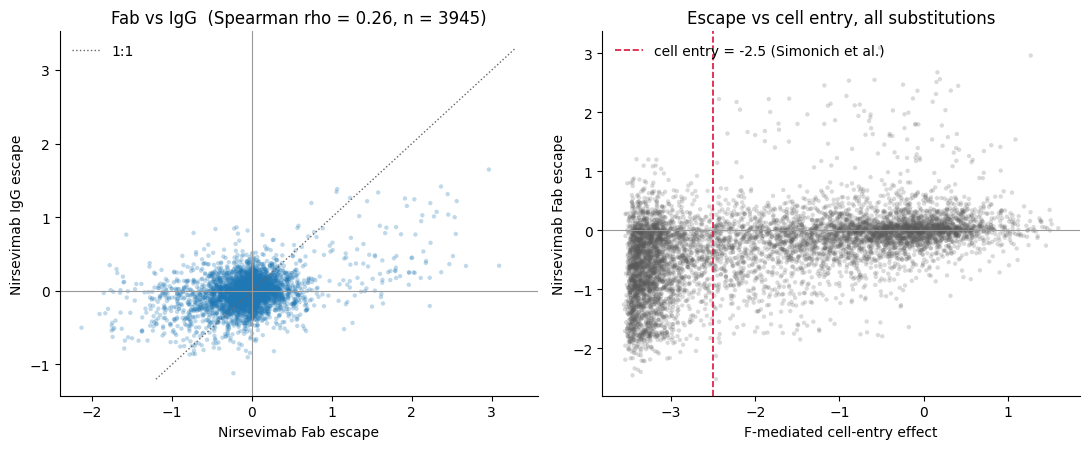

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

axes[0].scatter(both["Nirsevimab-Fab escape"], both["Nirsevimab-IgG escape"],
                s=10, alpha=0.28, edgecolors="none")
lim = (-1.2, 3.3)
axes[0].plot(lim, lim, ls=":", lw=1, color="0.4", label="1:1")
axes[0].axhline(0, lw=0.8, color="0.6")
axes[0].axvline(0, lw=0.8, color="0.6")
axes[0].set_xlabel("Nirsevimab Fab escape")
axes[0].set_ylabel("Nirsevimab IgG escape")
axes[0].set_title("Fab vs IgG  (Spearman rho = {:.2f}, n = {})".format(rho, len(both)))
axes[0].legend(frameon=False, loc="upper left")

axes[1].scatter(dms["cell entry"], dms["Nirsevimab-Fab escape"],
                s=10, alpha=0.22, edgecolors="none", color="0.35")
axes[1].axvline(CELL_ENTRY_MIN, ls="--", color="crimson", lw=1.2,
                label="cell entry = {} (Simonich et al.)".format(CELL_ENTRY_MIN))
axes[1].axhline(0, lw=0.8, color="0.6")
axes[1].set_xlabel("F-mediated cell-entry effect")
axes[1].set_ylabel("Nirsevimab Fab escape")
axes[1].set_title("Escape vs cell entry, all substitutions")
axes[1].legend(frameon=False, loc="upper left")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("../outputs/fig01_fab_igg_and_cell_entry.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. How concentrated is the escape signal?

This drives the statistical design in `../ANALYSIS_PLAN.md`. Nirsevimab binds a specific epitope, so
nearly all escape signal sits in a handful of sites, whereas EVEscape scores the whole protein
without any antibody information.

Two epitope definitions are reported below, because the choice roughly doubles the percentage and
only one of them is sourced:

* **narrow** — the nirsevimab contact window, sites 64–73 and 201–216. Antibody-specific, but the
  exact bounds are not traced to a citation in this package.
* **`region_0`** — antigenic site Ø as annotated by the DMS itself (Gilman et al., Rossey et al.;
  see `../REFERENCES.md`). Broader, and citable.

The qualitative conclusion does not depend on the choice: under either definition, almost every
strong-escape mutation falls inside the epitope.

In [10]:
NIRSEVIMAB_EPITOPE = [(64, 73), (201, 216)]

fab_rows = dms_functional[has_fab]
in_narrow = fab_rows.site.apply(lambda s: any(lo <= s <= hi for lo, hi in NIRSEVIMAB_EPITOPE))
in_region0 = fab_rows.region.eq("region_0")

print("Fab benchmark rows        : {}  across {} sites".format(len(fab_rows), fab_rows.site.nunique()))
print("  in epitope, narrow      : {:4d}  ({:.1%})".format(in_narrow.sum(), in_narrow.mean()))
print("  in epitope, region_0    : {:4d}  ({:.1%})".format(in_region0.sum(), in_region0.mean()))

for thr in (0.5, 1.0):
    strong = fab_rows["Nirsevimab-Fab escape"] > thr
    print("  Fab escape > {:<4}        : {:4d}   in narrow: {:4d}   in region_0: {:4d}".format(
        thr, strong.sum(), (strong & in_narrow).sum(), (strong & in_region0).sum()))

top50 = fab_rows.nlargest(50, "Nirsevimab-Fab escape")
print("\ntop-50 Fab-escape mutations span only {} sites: {}".format(
    top50.site.nunique(), sorted(int(s) for s in top50.site.unique())))
print("their antigenic regions:", top50.region.value_counts().to_dict())

Fab benchmark rows        : 3977  across 454 sites
  in epitope, narrow      :  343  (8.6%)
  in epitope, region_0    :  663  (16.7%)
  Fab escape > 0.5         :  227   in narrow:  135   in region_0:  142
  Fab escape > 1.0         :   98   in narrow:   93   in region_0:   95

top-50 Fab-escape mutations span only 12 sites: [64, 68, 73, 201, 204, 205, 206, 207, 208, 209, 210, 211]
their antigenic regions: {'region_0': 50}


## 9. Export and hash verification

In [11]:
benchmark = dms_functional[has_fab | has_igg][
    [
        "mutation",
        "site",
        "wildtype",
        "mutant",
        "Nirsevimab-Fab escape",
        "Nirsevimab-IgG escape",
        "cell entry",
        "region",
    ]
].copy()

# --- assertions: every documented property of the exported table ---
assert len(benchmark) == 4276, "row count changed: {}".format(len(benchmark))
assert benchmark.mutation.duplicated().sum() == 0
assert (benchmark.wildtype != benchmark.mutant).all()
assert benchmark["cell entry"].notna().all()
assert (benchmark["cell entry"] > CELL_ENTRY_MIN).all()
assert benchmark[["Nirsevimab-Fab escape", "Nirsevimab-IgG escape"]].notna().any(axis=1).all()
# missing values must remain missing - never imputed to zero
assert (benchmark["Nirsevimab-Fab escape"] == 0).sum() == 0
assert (benchmark["Nirsevimab-IgG escape"] == 0).sum() == 0

OUT = Path("../outputs/dms_nirsevimab_functional.csv")
OUT.parent.mkdir(parents=True, exist_ok=True)
benchmark.to_csv(OUT, index=False)

print("rows                  : {}".format(len(benchmark)))
print("sites                 : {}".format(benchmark.site.nunique()))
print("Fab missing (kept NaN): {}".format(benchmark["Nirsevimab-Fab escape"].isna().sum()))
print("IgG missing (kept NaN): {}".format(benchmark["Nirsevimab-IgG escape"].isna().sum()))
print("both missing          : {}  (must be 0)".format(
    benchmark[["Nirsevimab-Fab escape", "Nirsevimab-IgG escape"]].isna().all(axis=1).sum()))
print("\nwritten to", OUT)

rows                  : 4276
sites                 : 456
Fab missing (kept NaN): 299
IgG missing (kept NaN): 32
both missing          : 0  (must be 0)

written to ../outputs/dms_nirsevimab_functional.csv


In [12]:
def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

shipped = Path("../data/dms_nirsevimab_functional.csv")
h_new, h_ship = sha256(OUT), sha256(shipped)

print("regenerated :", h_new)
print("shipped     :", h_ship)
print("\nBYTE-IDENTICAL" if h_new == h_ship else "\n!! DIFFERS - investigate before sharing !!")
assert h_new == h_ship

regenerated : e83e20432e27133f48ba76de77b20b7df08e8ee2bed7372eada576cd82768051
shipped     : e83e20432e27133f48ba76de77b20b7df08e8ee2bed7372eada576cd82768051

BYTE-IDENTICAL


## 10. Summary

`data/dms_nirsevimab_functional.csv` contains **4,276 amino-acid substitutions** in RSV-A Long F,
each of which:

* is a real substitution (not a wildtype-identity row), with a unique ID in standard F numbering;
* has a measured cell-entry effect **> -2.5**, i.e. retains at least some moderate level of
  F-mediated cell-entry function under the assay, using the paper's own published criterion;
* has at least one nirsevimab escape measurement that survived the upstream precision filters.

**Deliberate non-claims.** These are *experimentally measured mutation effects*, not "ground truth".
`cell entry` measures F-mediated cell entry in a pseudovirus assay — it is not viral fitness, not
viability, and not transmissibility; the paper is explicit that "cell entry is only one of several F
properties that contribute to transmissibility". Missing values are censored measurements, not
zeros.

Next: **`02_reference_compatibility.ipynb`** establishes whether these mutation IDs can be merged
directly against RSV-A EVEscape scores.